# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [3]:
import os
from collections import defaultdict

import scanpy as sc

from matplotlib.pyplot import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import scvelo as scv
import cellrank as cr

In [5]:
import os

import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.feature_selection import mutual_info_regression
from scipy import stats

from drvi_notebooks.utils.data.data_configs import get_data_info
from drvi_notebooks.utils.run_info import get_run_info_for_dataset
from drvi_notebooks.utils.method_info import pretify_method_name

In [6]:
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [7]:
import mplscience
mplscience.available_styles()
mplscience.set_style()

['default', 'despine']


# Config

In [8]:
cwd = os.getcwd()

In [9]:
logs_dir = Path(os.path.expanduser('~/workspace/train_logs'))
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

In [10]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public')

In [11]:
output_dir = proj_dir / 'plots' / 'developmental_pancreas'
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

PosixPath('/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/plots/developmental_pancreas')

In [12]:
run_name = 'pancreas_scvelo'
run_version = '4.3'
run_path = os.path.expanduser('~/workspace/train_logs/models')

data_info = get_data_info(run_name, run_version)
wandb_address = data_info['wandb_address']
col_mapping = data_info['col_mapping']
plot_columns = data_info['plot_columns']
pp_function = data_info['pp_function']
data_path = data_info['data_path']
var_gene_groups = data_info['var_gene_groups']
cell_type_key = data_info['cell_type_key']
exp_plot_pp = data_info['exp_plot_pp']
control_treatment_key = data_info['control_treatment_key']
condition_key = data_info['condition_key']
split_key = data_info['split_key']

In [13]:
cat_10_pallete = sc.plotting.palettes.vega_10_scanpy
cat_10_pallete_without_grey = [c for c in cat_10_pallete if c != '#7f7f7f']
cat_20_pallete = sc.plotting.palettes.vega_20_scanpy
wong_pallete = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000",
]
cat_100_pallete = sc.plotting.palettes.godsnot_102

## Utils

In [14]:
original_params = plt.rcParams.copy()
def set_font_in_rc_params(fs = 16):
    plt.rcParams.update({
        'font.size': fs,            # General font size
        'axes.titlesize': fs,      # Title font size
        'axes.labelsize': fs,      # Axis label font size
        'legend.fontsize': fs,    # Legend font size
        'xtick.labelsize': fs,      # X-axis tick label font size
        'ytick.labelsize': fs       # Y-axis tick label font size
    })

## Data

In [15]:
adata_train = sc.read(data_path)
adata_train

AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'velocity_pseudotime', 'latent_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'in_cr_data', 'clusters_fine', 'day', 'proliferation', 'phase', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients', 'cr_prob_fate_Alpha', 'cr_prob_fate_Beta', 'cr_prob_fate_Epsilon', 'cr_prob_fate_Delta'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'all_norm_log1p', 'counts', 'scvelo_normalized', 'spliced', 'spliced_counts', 'spliced_norm_log1p', 'unspliced', 'unspliced_counts', 'unspliced_norm_log1p'
    obsp: 'connectivities', 'distances'

## Runs to load

In [16]:
run_info = get_run_info_for_dataset('pancreas_scvelo')
RUNS_TO_LOAD = run_info.run_dirs
scatter_point_size = run_info.scatter_point_size
adata_to_transfer_obs = run_info.adata_to_transfer_obs

for k,v in RUNS_TO_LOAD.items():
    if not os.path.exists(v):
        raise ValueError(f"{v} does not exists.")

In [17]:
embeds = {}
methods_to_consider = ["DRVI", "DRVI-IK", "scVI", "scETM", "MOFA", "LIGER", "PCA", "ICA", "MICHIGAN-opt", "TCVAE-opt"]

random_order = None
for method_name, run_path in RUNS_TO_LOAD.items():
    if method_name not in methods_to_consider:
        continue
    print(method_name)
    if str(run_path).endswith(".h5ad"):
        embed = sc.read(run_path)
    else:
        embed = sc.read(run_path / 'latent.h5ad')
    pp_function(embed)
    if random_order is None:
        random_order = embed.obs.sample(frac=1.).index
    embed = embed[random_order].copy()
    embeds[method_name] = embed

DRVI
DRVI-IK
scVI
PCA
ICA
MOFA
TCVAE-opt
MICHIGAN-opt
LIGER
scETM


In [18]:
new_cols = ['clusters_fine', 'cr_prob_fate_Alpha', 'cr_prob_fate_Beta', 'cr_prob_fate_Epsilon', 'cr_prob_fate_Delta']
col_mapping = {**col_mapping}
plot_columns = [*plot_columns]
col_mapping.update({
    'clusters_fine': 'Fine cell-type',
    'cr_prob_fate_Alpha': 'Alpha fate probability',
    'cr_prob_fate_Beta': 'Beta fate probability',
    'cr_prob_fate_Epsilon': 'Epsilon fate probability',
    'cr_prob_fate_Delta': 'Delta fate probability',
})
for col in new_cols:
    if col not in plot_columns:
        plot_columns.append(col)
for method_name, embed in embeds.items():
    for col in adata_train.obs.columns:
        if col not in embed.obs.columns:
            embed.obs[col] = adata_train.obs[col]

# Fate prediction

In [19]:
embeds

{'DRVI': AnnData object with n_obs × n_vars = 3696 × 32
     obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'velocity_pseudotime', 'latent_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'log_lib', '_scvi_labels', 'in_cr_data', 'clusters_fine', 'day', 'proliferation', 'phase', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients', 'cr_prob_fate_Alpha', 'cr_prob_fate_Beta', 'cr_prob_fate_Epsilon', 'cr_prob_fate_Delta'
     uns: 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_umap', 'qz_mean'
     varm: 'PCs'
     obsp: 'connectivities', 'distances',
 'DRVI-IK': AnnData object with n_obs × n_vars = 3696 × 32
     obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'velocity_pseudotime', 'latent_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'log_lib', '_scvi_labels', 'in_cr_data', 'clusters_fine', 'day', 'p

In [20]:
adata_scv = scv.datasets.pancreas()
adata_cr = cr.datasets.pancreas()
adata_scv, adata_cr

(AnnData object with n_obs × n_vars = 3696 × 27998
     obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
     var: 'highly_variable_genes'
     uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
     obsm: 'X_pca', 'X_umap'
     layers: 'spliced', 'unspliced'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 2531 × 27998
     obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime'
     var: 'highly_variable_genes'
     uns: 'clusters_colors', 'clusters_fine_colors', 'day_colors', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca'
     obsm: 'X_pca', 'X_umap'
     layers: 'spliced', 'unspliced'
     obsp: 'connectivities', 'distances')

In [21]:
def plot_tsi_on_ax(
    tsi_df,
    method_name='method',
    line_color='blue',
    optimal_color='k',
    n_macrostates=None,
    x_offset = (0.2, 0.2),
    y_offset = (0.1, 0.1),
    ax = None,
    total_score=None,
    **kwargs,
):
    if n_macrostates is not None:
        tsi_df = tsi_df.loc[tsi_df["number_of_macrostates"] <= n_macrostates, :]

    optimal_identification = tsi_df[["number_of_macrostates", "optimal_identification"]]
    optimal_identification = optimal_identification.rename(
        columns={"optimal_identification": "identified_terminal_states"}
    )
    optimal_identification["method"] = "Optimal identification"
    optimal_identification["line_style"] = "--"

    df = tsi_df[["number_of_macrostates", "identified_terminal_states"]]
    df["method"] = method_name
    df["line_style"] = "-"

    df = pd.concat([df, optimal_identification])

    sns.lineplot(
        data=df,
        x="number_of_macrostates",
        y="identified_terminal_states",
        hue="method",
        palette={method_name: line_color, 'Optimal identification': optimal_color},
        style="line_style",
        drawstyle="steps-post",
        ax=ax,
        **kwargs,
    )

    ax.set_xticks(df["number_of_macrostates"].unique().astype(int))
    # Plot is generated from large to small values on the x-axis
    for label_id, label in enumerate(ax.xaxis.get_ticklabels()[::-1]):
        if ((label_id + 1) % 5 != 0) and label_id != 0:
            label.set_visible(False)
    ax.set_yticks(df["identified_terminal_states"].unique())

    x_min = df["number_of_macrostates"].min() - x_offset[0]
    x_max = df["number_of_macrostates"].max() + x_offset[1]
    y_min = df["identified_terminal_states"].min() - y_offset[0]
    y_max = df["identified_terminal_states"].max() + y_offset[1]
    ax.set(
        xlim=[x_min, x_max],
        ylim=[y_min, y_max],
        xlabel="Number of macrostates",
        ylabel="Identified terminal states",
    )
    
    if total_score is not None:
        ax.text(0.5, 0.5, f"TSI score: {total_score:.2f}", transform=ax.transAxes)
    
    ax.get_legend().remove()

    n_methods = len(df["method"].unique())
    handles, labels = ax.get_legend_handles_labels()
    handles[n_methods].set_linestyle("--")
    handles = handles[: (n_methods + 1)]
    labels = labels[: (n_methods + 1)]
    labels[0] = "Method"
    ax.legend(handles=handles, labels=labels, loc="right", ncol=1, bbox_to_anchor=(1.0, 0.2))

In [22]:
method_palette = dict(zip(methods_to_consider, cat_20_pallete))

DRVI



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2531/2531 [00:01<00:00, 1642.17cell/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2531/2531 [00:01<00:00, 2122.66cell/s]


 53%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                                                | 1342/2531 [00:24<00:01, 1109.62cell/s]/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/home/icb/amirali.moinfar/miniconda

/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/home/icb/amirali.moinfar/miniconda3/envs/scvel

AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'macrostates_fwd', 'clusters_gradients', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'log1p', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'T_fwd_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'clusters_gradients_colors', 'term_states_fwd_colors'
    obsm: 'X_emb', 'X_pca', 'X_umap', 'T_fwd_umap', 'schur_vectors_fwd'

...

AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'macrostates_fwd', 'clusters_gradients', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'log1p', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'T_fwd_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'clusters_gradients_colors', 'term_states_fwd_colors'
    obsm: 'X_emb', 'X_pca', 'X_umap', 'T_fwd_umap', 'schur_vectors_fwd'


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2531/2531 [00:01<00:00, 1528.05cell/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2531/2531 [00:01<00:00, 2359.01cell/s]


/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)
/home/

/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/amirali.moinfar/miniconda3/envs/scvelo/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/home/icb/amirali.moinfar/miniconda3/envs/scvel

AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'macrostates_fwd', 'clusters_gradients', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'log1p', 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'T_fwd_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'clusters_gradients_colors', 'term_states_fwd_colors'
    obsm: 'X_emb', 'X_pca', 'X_umap', 'T_fwd_umap', 'schur_vectors_fwd'

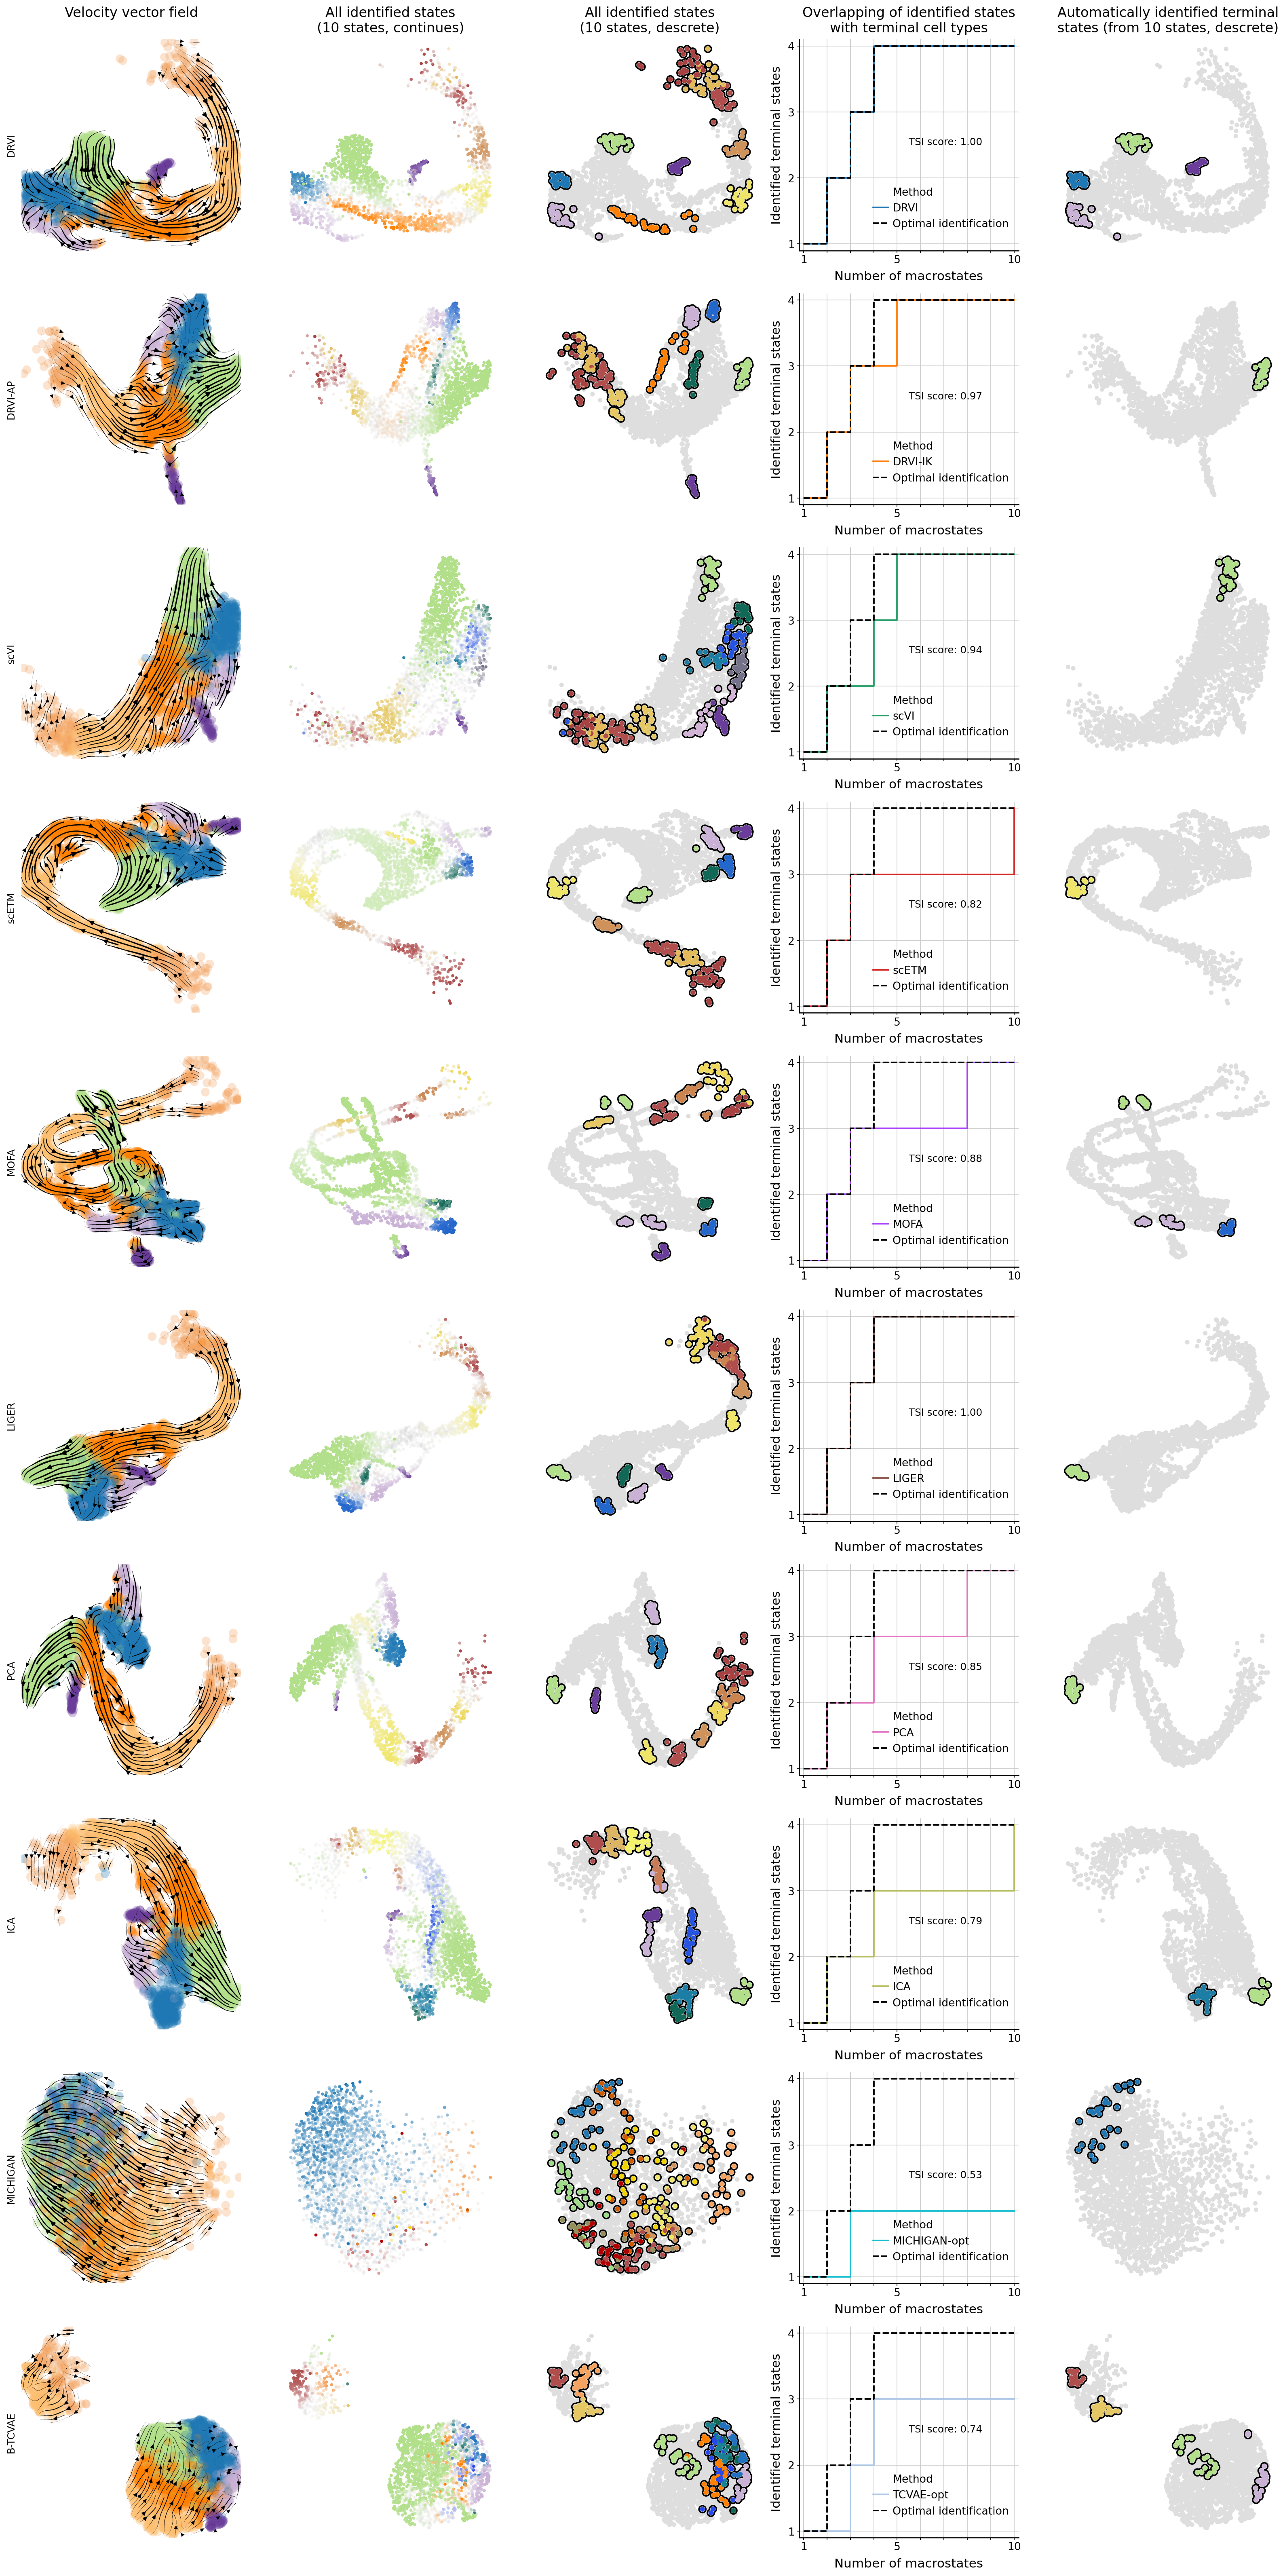

In [35]:
size = 4
fig, axs = plt.subplots(len(embeds), 5,
                        figsize=(5 * size, len(embeds) * size),
                        sharex=False, sharey=False, squeeze=False)
tsi_results = {}
auto_terminal_states_results = {}

for i, method_name in list(enumerate(methods_to_consider)):
    print(method_name)
    embed = embeds[method_name]

    if str(RUNS_TO_LOAD[method_name]).endswith(".h5ad"):
        vvf_filename = Path(str(RUNS_TO_LOAD[method_name])[:-5] + "___adata_with_scvelo_velocity_vf.h5ad")
    else:
        vvf_filename = RUNS_TO_LOAD[method_name] / "adata_with_scvelo_velocity_vf.h5ad"
    if not (vvf_filename).exists():
        adata = adata_scv.copy()
        
        scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
        # scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=False)  # TODO: also check this
        assert np.all(adata.var.index == adata_train.var.index)
        adata = adata[adata_cr.obs.index.str[:-4]].copy()  # Keep only cellrank cells
        
        basis = "emb"
        adata.obsm["X_emb"] = embed[adata.obs.index].X
        adata.obsm["X_umap"] = embed[adata.obs.index].obsm['X_umap']
        
        sc.pp.neighbors(adata, n_pcs=adata.obsm["X_emb"].shape[1], n_neighbors=30, use_rep='X_emb', random_state=0)
        scv.pp.moments(adata, n_pcs=adata.obsm["X_emb"].shape[1], n_neighbors=30)
    
        scv.tl.recover_dynamics(adata, n_jobs=16)
        scv.tl.velocity(adata, mode="dynamical")

        adata.write(vvf_filename)
    adata = sc.read(vvf_filename)

    vk = cr.kernels.VelocityKernel(adata)
    vk.compute_transition_matrix()

    vk.plot_projection(show=False, ax=axs[i, 0], legend_loc="none")
    # vk.plot_random_walks(start_ixs={"clusters": "Ngn3 low EP"}, max_iter=200, seed=0)

    successful_gpcca = False
    n_states = 10
    while not successful_gpcca:
        try:
            g = cr.estimators.GPCCA(vk)
            g.fit(cluster_key="clusters", n_states=n_states)
            successful_gpcca = True
        except Exception as e:
            n_states -= 1
            print('Error while fitting GPCCA:', e)
            print("New n_states:", n_states)
            
    g.plot_macrostates(which="all", discrete=True, legend_loc="none", s=100, show=False, ax=axs[i, 2])
    g.plot_macrostates(which="all", discrete=False, legend_loc="none", show=False, ax=axs[i, 1])

    tsi_score = g.tsi(n_macrostates=10, terminal_states=['Alpha', 'Beta', 'Delta', 'Epsilon'], cluster_key='clusters')
    tsi_results[method_name] = {'score': tsi_score, 'df': g._tsi.to_df()}
    plot_tsi_on_ax(g._tsi.to_df(), ax=axs[i, 3], method_name=method_name, line_color=method_palette[method_name], total_score=tsi_score)

    g.predict_terminal_states(method="eigengap")
    g.plot_macrostates(which="terminal", discrete=True, legend_loc="none", s=100, show=False, ax=axs[i, 4])
    # g.plot_macrostates(which="terminal", discrete=False, legend_loc="on data")

    auto_terminal_states_results[method_name] = {
        'terminal_states': g.terminal_states,
        'terminal_states_memberships': g.terminal_states_memberships,
        'terminal_states_probabilities': g.terminal_states_probabilities,
    }

    axs[i, 0].set_ylabel(pretify_method_name(method_name))
    
    axs[i, 0].grid(False)
    axs[i, 1].grid(False)
    axs[i, 2].grid(False)
    axs[i, 4].grid(False)

    axs[i, 0].set_title('Velocity vector field\n' if i == 0 else '')
    axs[i, 1].set_title('All identified states\n(10 states, continues)' if i == 0 else '')
    axs[i, 2].set_title('All identified states\n(10 states, descrete)' if i == 0 else '')
    axs[i, 3].set_title('Overlapping of identified states\nwith terminal cell types' if i == 0 else '')
    axs[i, 4].set_title('Automatically identified terminal\nstates (from 10 states, descrete)' if i == 0 else '')

plt.tight_layout()
plt.savefig(output_dir / f'cr_fate_mapping_for_all_methods.png', bbox_inches='tight', dpi=300)
plt.savefig(output_dir / f'cr_fate_mapping_for_all_methods.svg', bbox_inches='tight', dpi=300)
plt.show()

saving figure to file /ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/plots/developmental_pancreas/cr_fate_mapping_for_all_methodslegend.svg


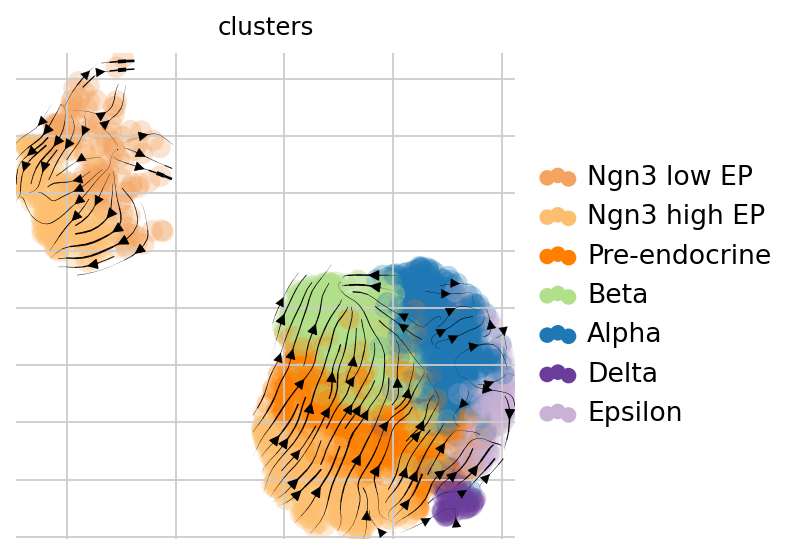

In [36]:
vk.plot_projection(legend_loc="right margin", save=str(output_dir / f'cr_fate_mapping_for_all_methodslegend.svg'))

## Plotting as metrics

In [58]:
def find_auto_identified_terminals_score(terminal_states_series):
    set1 = set([x.split("_")[0] for x in terminal_states_series.dropna().unique()])
    print(set1)
    set2 = ['Delta', 'Epsilon', 'Alpha', 'Beta']
    return len(set1.intersection(set2)) / len(set1.union(set2))

tsi_scores = {method_name: tsi_results[method_name]['score'] for method_name in tsi_results}
auto_identified_terminals = {method_name: find_auto_identified_terminals_score(auto_terminal_states_results[method_name]['terminal_states']) 
                             for method_name in auto_terminal_states_results}

{'Alpha', 'Beta', 'Epsilon', 'Delta'}
{'Beta'}
{'Beta'}
{'Ngn3 high EP'}
{'Alpha', 'Beta', 'Epsilon'}
{'Beta'}
{'Beta'}
{'Alpha', 'Beta'}
{'Alpha'}
{'Ngn3 high EP', 'Epsilon', 'Beta'}


In [59]:
tsi_scores

{'DRVI': 1.0,
 'DRVI-IK': 0.9705882352941176,
 'scVI': 0.9411764705882353,
 'scETM': 0.8235294117647058,
 'MOFA': 0.8823529411764706,
 'LIGER': 1.0,
 'PCA': 0.8529411764705882,
 'ICA': 0.7941176470588235,
 'MICHIGAN-opt': 0.5294117647058824,
 'TCVAE-opt': 0.7352941176470589}

In [60]:
auto_identified_terminals

{'DRVI': 1.0,
 'DRVI-IK': 0.25,
 'scVI': 0.25,
 'scETM': 0.0,
 'MOFA': 0.75,
 'LIGER': 0.25,
 'PCA': 0.25,
 'ICA': 0.5,
 'MICHIGAN-opt': 0.25,
 'TCVAE-opt': 0.4}

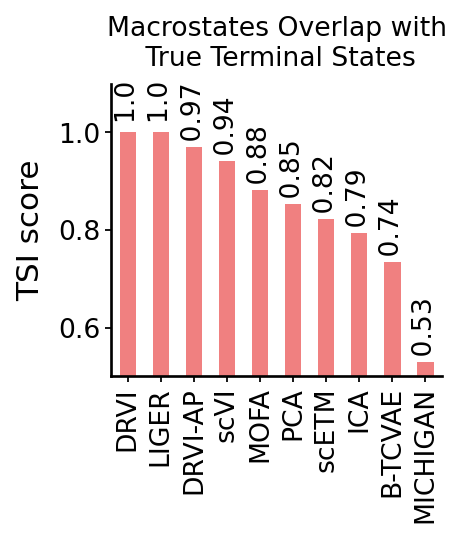

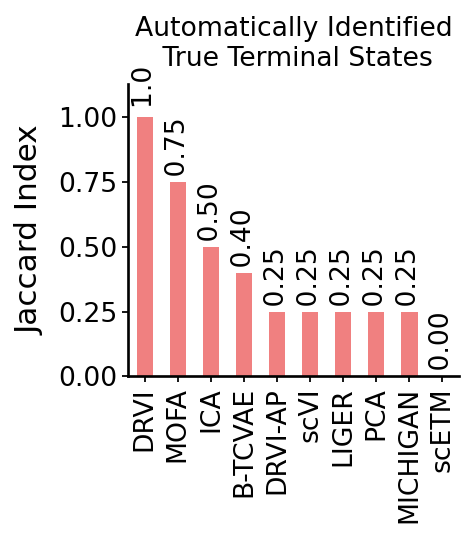

In [92]:
for idx, (plot_data, title, y_label) in enumerate([
    (tsi_scores, 'Macrostates Overlap with\n True Terminal States', 'TSI score'),
    (auto_identified_terminals, 'Automatically Identified\n True Terminal States', 'Jaccard Index'),
]):
    plot_data = {pretify_method_name(k): v for k, v in plot_data.items()}
    plot_series = pd.Series(plot_data).sort_values(ascending=False)

    plt.figure(figsize=(3, 3.5))
    ax = plot_series.plot(kind='bar', color='lightcoral')
    ax.grid(False)
    plt.title(f"{title}", fontsize=12)
    plt.xlabel('', fontsize=12)
    plt.ylabel(f"{y_label}", fontsize=14)
    plt.xticks(rotation=90)

    # Change min y-axis for the first plot only
    if idx == 0:
        plt.ylim(0.5, 1.1)
    else:
        plt.ylim(0., 1.13)

    # Add score labels on top of each bar
    for p in ax.patches:
        ax.annotate(f"   {p.get_height():.2f}" if p.get_height() != 1. else "  1.0",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=12,
                    rotation=90) # Rotate the text by 90 degrees

    plt.tight_layout()
    plt.savefig(output_dir / f'tsi_score_plot_{idx+1}_updated.pdf')
    plt.savefig(output_dir / f'tsi_score_plot_{idx+1}_updated.png')
    plt.show()